# Session 08 02 2026
On that date I recorded a new session - I labeled the date so that I can validate the predictions of the current model

## Load model
First we are going to load the trained model from ML Flow

In [1]:
import sys
from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data_pipeline.database import save_to_db, initialize_tables, update_pipeline_run_status
from infra.db.database_utils import DatabaseFactory
import os
from infra.db.database_utils import DatabaseEngine, get_postgres_db_engine

import logging
logger = logging.getLogger(__name__)
import mlflow
from load_model import load_production_model


MLFLOW_TRACKING_URI = os.getenv("MLFLOW_BACKEND_STORE_URI", None)
if MLFLOW_TRACKING_URI is None:
    raise ValueError("MLFLOW_TRACKING_URI environment variable is not set.")
MODEL_NAME = os.getenv("MODEL_NAME", "HAR_xgboost")
MODEL_ALIAS = os.getenv("MODEL_ALIAS", "production")

db_engine = get_postgres_db_engine()

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# LOAD MODEL AND SCALER
model, scaler = load_production_model(MODEL_NAME, MODEL_ALIAS)
print(f"Loaded model: {MODEL_NAME} with alias: {MODEL_ALIAS}")

if scaler:
    print("Scaler is available for data transformation.")
else:
    print("WARNING: No scaler loaded. Predictions on raw data may be incorrect.")

print(f"\nModel input schema:")
if hasattr(model, 'metadata') and model.metadata.signature:
    input_schema = model.metadata.signature.inputs
    print(f"  Expected features: {len(input_schema.input_names())}")
    print(f"  First 5 features: {input_schema.input_names()[:5]}")
else:
    print("  No signature found in model metadata")


2026/02/08 16:46:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/08 16:46:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/08 16:46:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/08 16:46:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/08 16:46:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/08 16:46:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments


Loading model from MLflow URI: models:/HAR_xgboost@production


2026/02/08 16:46:32 INFO alembic.runtime.migration: Context impl PostgresqlImpl.
2026/02/08 16:46:32 INFO alembic.runtime.migration: Will assume transactional DDL.


✓ Scaler loaded successfully
Loaded model: HAR_xgboost with alias: production
Scaler is available for data transformation.

Model input schema:
  No signature found in model metadata


model is loaded so time to run last processing and predictions

this is raw data. first we need to run it through data processing pipeline

In [2]:
from data_pipeline.process_raw_data import process_raw_sensor_data
import pandas as pd
import os

labels_with_timestamps_path = r"E:\src\neat-calculator\ml_monolith\data_preprocessing\label_files_08022026\merged_labels.csv"

print(f"\n{'='*50}")
print("Processing raw sensor data...")

try:
    processed_data = process_raw_sensor_data(
        raw_data_file_dir=r"E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\08022026",
        kaggle_csv_path="E:\\src\\neat-calculator\\ml_monolith\\kaggle.csv",
        labels_csv_path=labels_with_timestamps_path,
        version="2"
    )
    print(f"✅ Processing successful!")
    print(f"  Data shape: {processed_data.shape}")
    print(f"  Columns: {list(processed_data.columns)}")
    
    if 'Activity' in processed_data.columns:
        print(f"  Activity distribution:")
        print(processed_data['Activity'].value_counts())
    else:
        print("  No Activity column found - processed without labels")
        
    processed_data.head()
    
except Exception as e:
    print(f"❌ Processing failed: {str(e)}")
    print(f"Error type: {type(e).__name__}")
    


2026-02-08 16:46:44,757 - data_pipeline.process_raw_data - INFO - Starting processing of raw data in directory: E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\08022026
2026-02-08 16:46:44,758 - data_pipeline.process_raw_data - INFO - Using labels from: E:\src\neat-calculator\ml_monolith\data_preprocessing\label_files_08022026\merged_labels.csv
2026-02-08 16:46:44,759 - data_pipeline.process_raw_data - INFO - Validating directory: E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\08022026
2026-02-08 16:46:44,760 - data_pipeline.process_raw_data - INFO - Directory E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\08022026 exists.
2026-02-08 16:46:44,761 - data_pipeline.process_raw_data - INFO - Path E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\08022026 is a directory.
2026-02-08 16:46:44,761 - data_pipeline.process_raw_data - INFO - Directory E:\src\neat-calculator\data


Processing raw sensor data...


2026-02-08 16:46:44,960 - data_pipeline.process_raw_data - INFO - Total sensor data points: 9523
2026-02-08 16:46:44,960 - data_pipeline.process_raw_data - INFO - Timestamp range: 1770556157833 to 1770561221448
2026-02-08 16:46:44,960 - data_pipeline.process_raw_data - INFO - Processing 10 labels...
2026-02-08 16:46:44,960 - data_pipeline.process_raw_data - INFO - 
Label 1: Stairs Down
2026-02-08 16:46:44,960 - data_pipeline.process_raw_data - INFO -   Original range: 1770556164324 to 1770556199074
2026-02-08 16:46:44,970 - data_pipeline.process_raw_data - INFO -   Buffered range: 1770556169324 to 1770556194074
--- Logging error ---
Traceback (most recent call last):
  File "C:\Python310\lib\logging\__init__.py", line 1101, in emit
    stream.write(msg + self.terminator)
  File "C:\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 68

<class 'pandas.core.frame.DataFrame'>
Index: 9523 entries, 535 to 7273
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   accelerometerX  9523 non-null   float64
 1   accelerometerY  9523 non-null   float64
 2   accelerometerZ  9523 non-null   float64
 3   gyroscopeX      9523 non-null   float64
 4   gyroscopeY      9523 non-null   float64
 5   gyroscopeZ      9523 non-null   float64
 6   timestamp       9523 non-null   int64  
 7   timestampNanos  9523 non-null   int64  
 8   label           3003 non-null   object 
dtypes: float64(6), int64(2), object(1)
memory usage: 744.0+ KB
{'accelerometerX': 'mean', 'accelerometerY': 'mean', 'accelerometerZ': 'mean', 'gyroscopeX': 'mean', 'gyroscopeY': 'mean', 'gyroscopeZ': 'mean'}
{'accelerometerX': 'mean', 'accelerometerY': 'mean', 'accelerometerZ': 'mean', 'gyroscopeX': 'mean', 'gyroscopeY': 'mean', 'gyroscopeZ': 'mean', 'label': 'first', 'timestamp': 'first'}


2026-02-08 16:46:45,841 - data_pipeline.process_raw_data - INFO - Median delta time: 0.02 seconds
2026-02-08 16:46:45,842 - data_pipeline.process_raw_data - INFO - Estimated frequency: 50.0 Hz
2026-02-08 16:46:45,843 - data_pipeline.process_raw_data - INFO - Resampling completed.
2026-02-08 16:46:45,844 - data_pipeline.process_raw_data - INFO - Columns after resampling: ['accelerometerX', 'accelerometerY', 'accelerometerZ', 'gyroscopeX', 'gyroscopeY', 'gyroscopeZ', 'label', 'timestamp', 'dt', 'dt_seconds']
2026-02-08 16:46:45,845 - data_pipeline.process_raw_data - INFO - Creating sliding windows with window size: 128, step size: 64
2026-02-08 16:46:45,847 - data_pipeline.process_raw_data - INFO - Identifying session breaks based on time gaps. A session means a singular recording session without big time gaps.
2026-02-08 16:46:45,849 - data_pipeline.process_raw_data - INFO - Number of sessions: 9
2026-02-08 16:46:45,914 - data_pipeline.process_raw_data - INFO - Sliding windows created.


                         dt_seconds  session_id
t                                              
2026-02-08 13:09:29.580        0.00           0
2026-02-08 13:09:29.600        0.02           0
2026-02-08 13:09:29.620        0.02           0
2026-02-08 13:09:29.640        0.02           0
2026-02-08 13:09:29.660        0.02           0
2026-02-08 13:09:29.680        0.02           0
2026-02-08 13:09:29.700        0.02           0
2026-02-08 13:09:29.720        0.02           0
2026-02-08 13:09:29.740        0.02           0
2026-02-08 13:09:29.760        0.02           0
Number of windows: 195
Window shape: (128, 6)
Example labels: ['SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS' 'WALKING_UPSTAIRS']


2026-02-08 16:46:47,374 - data_pipeline.process_raw_data - INFO - Shape of features: (195, 212)
2026-02-08 16:46:47,374 - data_pipeline.process_raw_data - INFO - Feature columns: Index(['tBodyAcc-mean()-X', 'tBodyAcc-std()-X', 'tBodyAcc-min()-X',
       'tBodyAcc-max()-X', 'tBodyAcc-energy()-X', 'tBodyAcc-entropy()-X',
       'tBodyAcc-mean()-Y', 'tBodyAcc-std()-Y', 'tBodyAcc-min()-Y',
       'tBodyAcc-max()-Y',
       ...
       'fBodyGyroMag-mean()', 'fBodyGyroMag-std()', 'fBodyGyroMag-energy()',
       'fBodyGyroMag-entropy()', 'fBodyGyroMag-meanFreq()',
       'fBodyGyroJerkMag-mean()', 'fBodyGyroJerkMag-std()',
       'fBodyGyroJerkMag-energy()', 'fBodyGyroJerkMag-entropy()',
       'fBodyGyroJerkMag-meanFreq()'],
      dtype='object', length=212)
2026-02-08 16:46:47,374 - data_pipeline.process_raw_data - INFO - Feature extraction completed.
2026-02-08 16:46:47,374 - data_pipeline.process_raw_data - INFO - Renaming features for clarity.
2026-02-08 16:46:47,374 - data_pipeline.proc

✅ Processing successful!
  Data shape: (195, 182)
  Columns: ['tBodyAcc-mean()-X', 'tBodyAcc-std()-X', 'tBodyAcc-min()-X', 'tBodyAcc-max()-X', 'tBodyAcc-energy()-X', 'tBodyAcc-entropy()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-std()-Y', 'tBodyAcc-min()-Y', 'tBodyAcc-max()-Y', 'tBodyAcc-energy()-Y', 'tBodyAcc-entropy()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-Z', 'tBodyAcc-min()-Z', 'tBodyAcc-max()-Z', 'tBodyAcc-energy()-Z', 'tBodyAcc-entropy()-Z', 'tBodyGyro-mean()-X', 'tBodyGyro-std()-X', 'tBodyGyro-min()-X', 'tBodyGyro-max()-X', 'tBodyGyro-energy()-X', 'tBodyGyro-entropy()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-std()-Y', 'tBodyGyro-min()-Y', 'tBodyGyro-max()-Y', 'tBodyGyro-energy()-Y', 'tBodyGyro-entropy()-Y', 'tBodyGyro-mean()-Z', 'tBodyGyro-std()-Z', 'tBodyGyro-min()-Z', 'tBodyGyro-max()-Z', 'tBodyGyro-energy()-Z', 'tBodyGyro-entropy()-Z', 'tGravityAcc-mean()-X', 'tGravityAcc-std()-X', 'tGravityAcc-min()-X', 'tGravityAcc-max()-X', 'tGravityAcc-energy()-X', 'tGravityAcc-entropy()-X', 'tGrav

Okay we processed the data so time to fit it

In [3]:
 # Use balanced data for prediction
import pandas as pd
from sklearn.preprocessing import LabelEncoder

filtered_data = processed_data

columns_to_drop = ["Activity", "timestamp"]
feature_columns = [col for col in filtered_data.columns if col not in columns_to_drop]

# ORIGINAL RAW DATA
# Extract raw features from processed data
X= filtered_data[feature_columns]
y = filtered_data["Activity"].to_numpy()

print(f"Feature matrix shape: {X.shape}")
print(f"Raw Data range: [{X.min().min():.2f}, {X.max().max():.2f}]")

# APPLY SCALER IF AVAILABLE
if scaler:
    print("Applying scaler to input data...")
    # Filter columns that scaler expects
    # (Assuming scaler was fit on same feature set. If mismatch, we might need intersection)
    try:
        X_scaled = scaler.transform(X)
        print(f"Scaled Data range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
        # Make predictions using the SCALED data
        predictions = model.predict(X_scaled)          # Returns integer labels
        probabilities = model.predict_proba(X_scaled)  # Probability matrix
    except Exception as e:
        print(f"Scaling failed: {e}")
        print("Falling back to raw data (results may be poor)")
        predictions = model.predict(X)
        probabilities = model.predict_proba(X)
else:
    print("WARNING: Using raw unscaled data.")
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)


print(f"\nPredictions shape: {predictions.shape}")
print(f"Probabilities shape: {probabilities.shape}")
print(f"\nFirst 5 predictions (integers): {predictions[:5]}")
print(f"First prediction probabilities: {probabilities[0]}")


Feature matrix shape: (195, 180)
Raw Data range: [-613.00, 66157.32]
Applying scaler to input data...
Scaled Data range: [-1.00, 1.11]

Predictions shape: (195,)
Probabilities shape: (195, 6)

First 5 predictions (integers): [4 4 4 4 4]
First prediction probabilities: [3.8318234e-04 6.7117898e-04 1.0543611e-03 4.1171061e-03 9.9337113e-01
 4.0301419e-04]


In [ ]:
y

In [4]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# The model was trained with LabelEncoder which sorts classes alphabetically by default
known_classes = ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
le = LabelEncoder()
le.fit(known_classes)

# Inspect inputs
print(f"Type of y: {y.dtype}")
print(f"Type of predictions: {predictions.dtype}")
print(f"Unique values in predictions: {np.unique(predictions)}")

# Handle potential classes falling outside known classes
# It seems the model predicts a class (e.g., 6) that is outside the range 0-5.
# This can happen if the model was trained with more classes or if something is wrong.
# We will clip or map unknown classes to a placeholder or nearest valid class.

if np.issubdtype(predictions.dtype, np.number):
    print("Converting predictions from integers to string labels...")
    
    # Check for invalid labels
    invalid_mask = ~np.isin(predictions, np.arange(len(known_classes)))
    if invalid_mask.any():
        print(f"WARNING: Found {np.sum(invalid_mask)} predictions with invalid labels: {np.unique(predictions[invalid_mask])}")
        print("Mapping invalid labels to 'UNKNOWN' (or handling gracefully)")
        # Option 1: Clip to valid range (dangerous if mapping is wrong)
        # Option 2: Replace with dummy (-1) and handle transform manually
        
        # Here we'll convert manually to be safe
        pred_strings = []
        for p in predictions:
            if 0 <= p < len(known_classes):
                pred_strings.append(known_classes[p])
            else:
                pred_strings.append("UNKNOWN")
        predictions = np.array(pred_strings)
    else:
        predictions = le.inverse_transform(predictions.astype(int))

# Ensure y is string
y = y.astype(str)

print(f"First 5 ground truth: {y[:5]}")
print(f"First 5 predictions:  {predictions[:5]}")

Type of y: object
Type of predictions: int64
Unique values in predictions: [1 2 3 4 5]
Converting predictions from integers to string labels...
First 5 ground truth: ['WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS']
First 5 predictions:  ['WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS']


In [5]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Fix Label Mapping
# The model was trained with LabelEncoder which sorts classes alphabetically by default/standard HAR.
known_classes = ['LAYING','WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'WALKING',  'WALKING_UPSTAIRS']
le = LabelEncoder()
le.fit(known_classes)

# Inspect inputs
print(f"Type of y: {y.dtype}")
print(f"Type of predictions: {predictions.dtype}")

# Convert predictions (integers) back to string labels to match y
if np.issubdtype(predictions.dtype, np.number):
    print("Converting predictions from integers to string labels...")
    predictions = le.inverse_transform(predictions.astype(int))

# Ensure y is string
y = y.astype(str)

print(f"First 5 ground truth: {y[:5]}")
print(f"First 5 predictions:  {predictions[:5]}")


# 2. Check Feature Scaling (Likely Cause of Bad Performance)
# Kaggle HAR data is normalized to [-1, 1]. 
# Any values outside this range indicate a scaling mismatch using raw features.
print("\n--- Feature Scaling Check ---")
min_val = processed_data[feature_columns].min().min()
max_val = processed_data[feature_columns].max().max()
print(f"Min feature value: {min_val:.4f}")
print(f"Max feature value: {max_val:.4f}")

if min_val < -1.5 or max_val > 1.5:
    print("\n[WARNING] Feature values are outside the expected [-1, 1] range.")
    print("The model expects normalized data. Raw physical units will cause poor performance.")
    
    # Show top features violating range
    means = processed_data[feature_columns].mean()
    print("\nTop 5 features with highest mean values (likely unnormalized):")
    print(means.nlargest(5))
else:
    print("\n[OK] Feature values seem to be within normalized range.")

Type of y: <U18
Type of predictions: <U18
First 5 ground truth: ['WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS']
First 5 predictions:  ['WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS']

--- Feature Scaling Check ---
Min feature value: -613.0000
Max feature value: 66157.3225

[WARNING] Feature values are outside the expected [-1, 1] range.
The model expects normalized data. Raw physical units will cause poor performance.

Top 5 features with highest mean values (likely unnormalized):
fBodyAccJerk-energy()-X      7533.122803
fBodyAccJerk-energy()-Z      7246.514864
fBodyAccJerk-energy()-Y      5024.878959
tBodyGyroJerkMag-energy()    1376.202935
tBodyGyroJerk-energy()-Y      935.777651
dtype: float64


Accuracy: 0.9949

Classification Report:
                    precision    recall  f1-score   support

           SITTING       1.00      1.00      1.00        64
          STANDING       1.00      1.00      1.00        24
           WALKING       0.97      1.00      0.99        35
WALKING_DOWNSTAIRS       1.00      0.98      0.99        47
  WALKING_UPSTAIRS       1.00      1.00      1.00        25

          accuracy                           0.99       195
         macro avg       0.99      1.00      1.00       195
      weighted avg       1.00      0.99      0.99       195



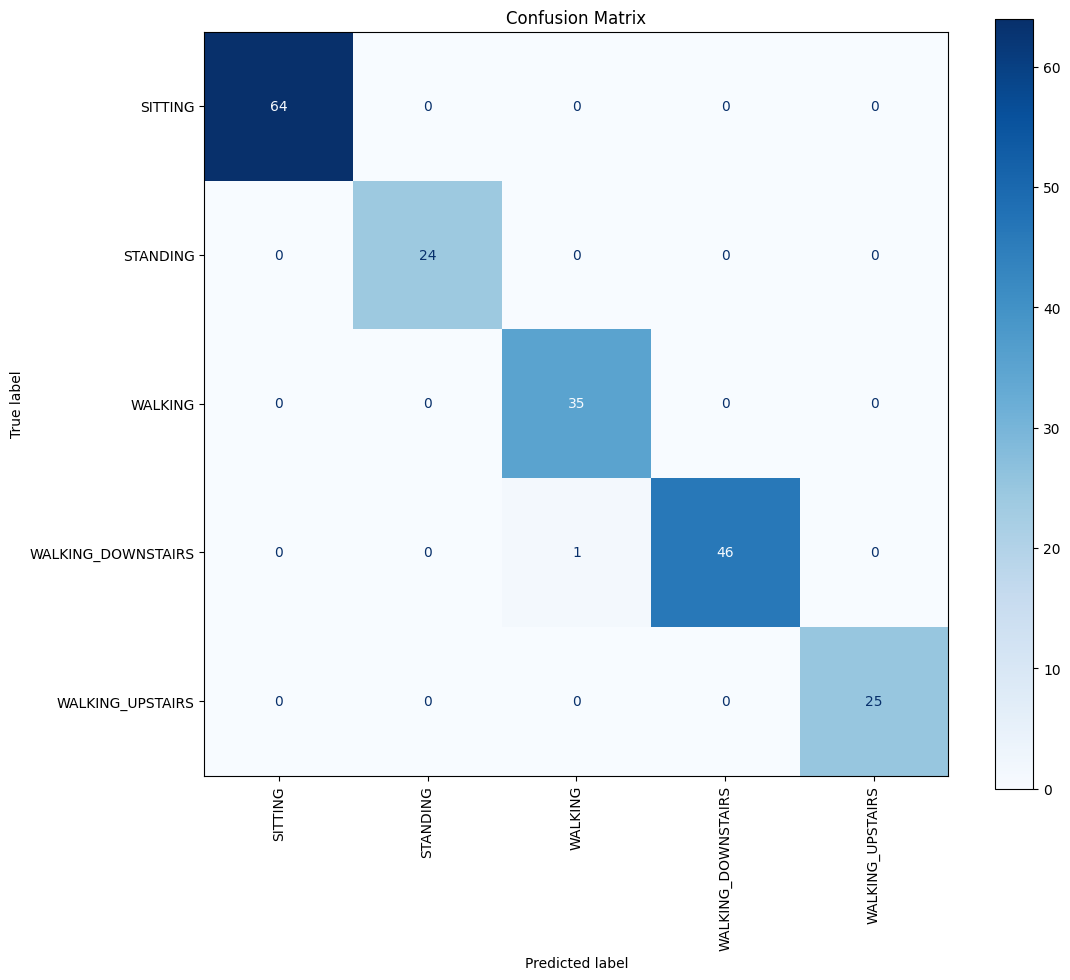

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Calculate accuracy
accuracy = accuracy_score(y, predictions)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y, predictions))

# Confusion Matrix
# Ensure we capture all classes present in data and predictions
labels = np.unique(np.concatenate((y, predictions)))

fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y, predictions, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

### Scaling Issue Identified
The model was trained on a combined dataset (Kaggle + Custom) where Kaggle data was scaled to [-1, 1] but Custom data was likely unscaled. This mixed distribution confuses the model.

**Next Steps:**
1. We have updated `train_model.py` to include `MinMaxScaler`.
2. You need to **re-run the training script** to generate a corrected model.
3. Then, reload the model here.


In [ ]:
# Re-training instructions
# To address the scaling mismatch, I've updated 'train_model.py' to scale your custom data to [-1, 1] before combining with Kaggle data.
# Please run the updated training script from the terminal:
# python ml_monolith/model_training/train_model.py


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Debug: Visualize Feature Variance vs Labels to Check Alignment
# "Walking" should have high variance (std/energy), "Standing" should be near zero.

plt.figure(figsize=(20, 6))

# Choose a key feature representing intensity
metric = "tBodyAcc-std()-X"  # Standard deviation of body acceleration (Jerk/Energy proxy)

if metric not in filtered_data.columns:
    print(f"Feature {metric} not found. Using first available feature.")
    metric = filtered_data.columns[0]

# Plot the feature value
sns.lineplot(data=filtered_data, x="timestamp", y=metric, label=metric, color='blue', alpha=0.6)

# Overlay the ground truth labels
# We create diverse colors for activities
unique_activities = filtered_data["Activity"].unique()
palette = sns.color_palette("hsv", len(unique_activities))
activity_colors = dict(zip(unique_activities, palette))

# Create a "step" plot for labels (scaled to fit the graph)
# Mapping labels to a numeric y-value for visualization? 
# Better: shade the background or add a scatter plot.
# Let's add a scatter plot on top for the labels.

# Map activities to y-positions or just color
# We'll plot points at the top of the graph colored by activity
max_y = filtered_data[metric].max()
sns.scatterplot(data=filtered_data, x="timestamp", y=max_y * 1.1, hue="Activity", palette=palette, s=50, marker="o")

plt.title(f"Activity Signals Analysis: {metric} vs Time")
plt.ylabel("Signal Intensity (Std Dev)")
plt.xlabel("Time")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Histogram check
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_data, x="Activity", y=metric)
plt.title(f"Distribution of {metric} by Activity Label")
plt.xticks(rotation=45)
plt.show()
